# Requirement Setup

In [1]:
!pip install prophet
!pip install scikit-learn
!pip install tensorflow
!pip install setuptools
!pip install keras-tuner

In [2]:
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
import numpy as np
import time
import matplotlib.pyplot as plt
from datetime import datetime
from prophet.serialize import model_to_json, model_from_json

Importing plotly failed. Interactive plots will not work.


Enable / Disable Hyperparameter Tuning

In [3]:
HYPERPARAMETER_TUNING = False

In [4]:
np.random.seed(42)
tf.random.set_seed(42)

# Data Loading

In [5]:
df_nasa = pd.read_csv('datasets/nasa.csv')
df_nasa.columns = ['ds', 'y']
df_nasa['ds'] = pd.to_datetime(df_nasa['ds'])

print(f'NASA DATASET - Dates: {df_nasa["ds"].count()} | Total: {df_nasa["y"].sum()}')
df_nasa.head()

NASA DATASET - Dates: 81396 | Total: 3461612


,ds,y
0,1995-07-01 00:00:00,42
1,1995-07-01 00:01:00,61
2,1995-07-01 00:02:00,57
3,1995-07-01 00:03:00,71
4,1995-07-01 00:04:00,70


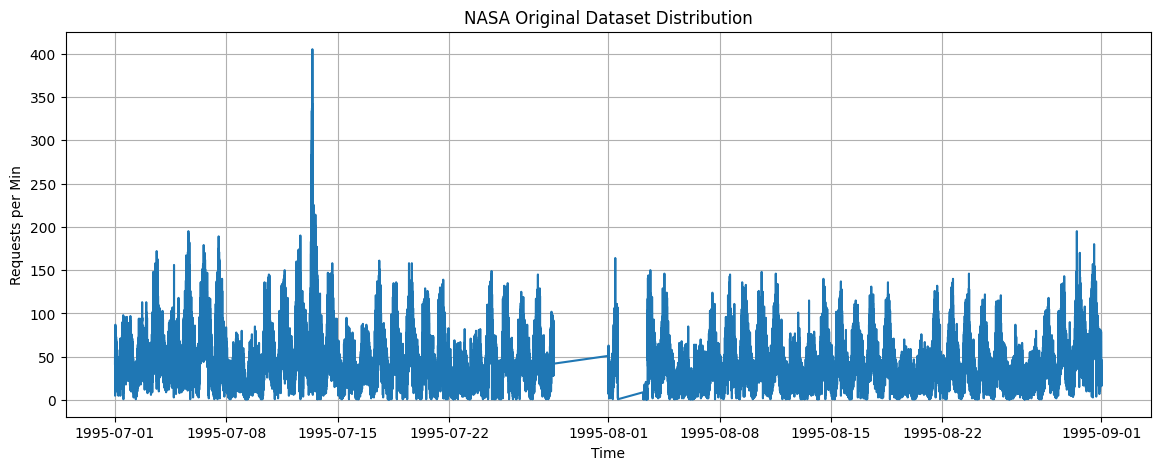

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df_nasa['ds'], df_nasa['y'])
plt.title('NASA Original Dataset Distribution')
plt.xlabel('Time')
plt.ylabel('Requests per Min')
plt.grid(True)
plt.savefig("images/nasa-original.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

# Data Splitting & Preprocessing

1.   Split datasets as 70% training, 30% testing
2.   Fill for empty data
3.   Drop duplicate data

In [7]:
train_df_nasa, test_df_nasa = train_test_split(df_nasa, test_size=0.3, random_state=42, shuffle=False)

print(f'NASA DATASET: Train Set: {train_df_nasa.shape} | Test Set: {test_df_nasa.shape}')

NASA DATASET: Train Set: (56977, 2) | Test Set: (24419, 2)


In [8]:
train_df_nasa['y'].fillna(method='ffill', inplace=True)
train_df_nasa.drop_duplicates(subset='ds', inplace=True)

print(f'NASA DATASET: Train Set: {train_df_nasa.shape} | Test Set: {test_df_nasa.shape}')

NASA DATASET: Train Set: (56977, 2) | Test Set: (24419, 2)


C:\Users\dilee\AppData\Local\Temp\ipykernel_27980\2063219103.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df_nasa['y'].fillna(method='ffill', inplace=True)
C:\Users\dilee\AppData\Local\Temp\ipykernel_27980\2063219103.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df_nasa['y'].fillna(method='ffill', inplace=True)


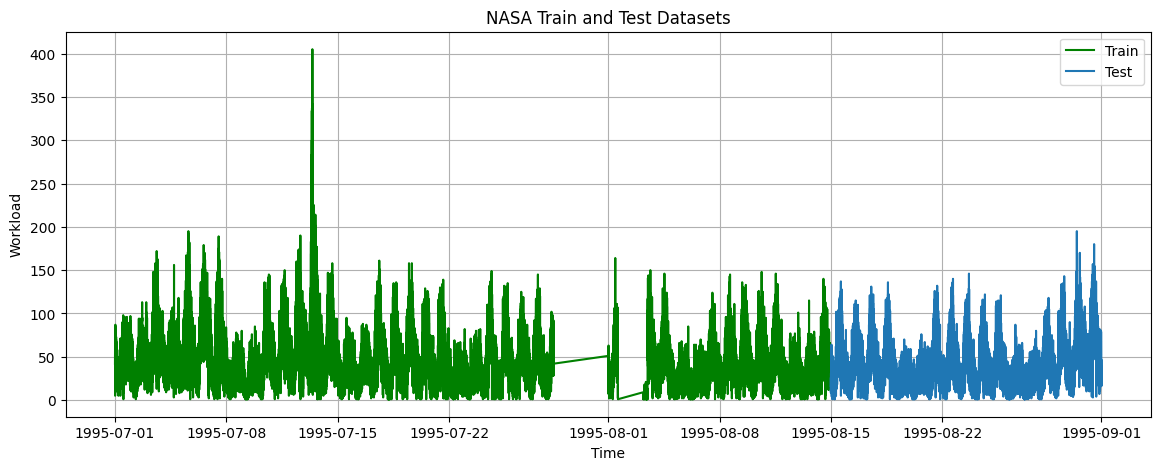

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(train_df_nasa['ds'], train_df_nasa['y'], label='Train', color='green')
plt.plot(test_df_nasa['ds'], test_df_nasa['y'], label='Test', color='#1f77b4')
plt.title('NASA Train and Test Datasets')
plt.xlabel('Time')
plt.ylabel('Workload')
plt.grid(True)
plt.legend()
plt.savefig("images/nasa-train-test.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

# Model Training

## Seasonality Capturing with Prophet

### Train Model

In [10]:
model_one = Prophet(
    growth='linear',
    changepoint_prior_scale=5.1,
    yearly_seasonality=False,
    weekly_seasonality=20,
    daily_seasonality=50,
    seasonality_prior_scale=30
)
model_one.fit(train_df_nasa)

22:10:04 - cmdstanpy - INFO - Chain [1] start processing
22:11:55 - cmdstanpy - INFO - Chain [1] done processing


### Predict Dataset

In [11]:
forecast_train_df_nasa = model_one.predict(train_df_nasa[['ds']].copy())

start_time = time.time()
forecast_test_df_nasa = model_one.predict(test_df_nasa[['ds']].copy())
end_time = time.time()

In [12]:
forecast_test_df_nasa_analysis = test_df_nasa.copy()
forecast_test_df_nasa_analysis = forecast_test_df_nasa_analysis.merge(forecast_test_df_nasa[['ds', 'yhat']], on='ds', how='left')

mse = mean_squared_error(forecast_test_df_nasa_analysis['y'], forecast_test_df_nasa_analysis['yhat'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(forecast_test_df_nasa_analysis['y'], forecast_test_df_nasa_analysis['yhat'])
r2 = r2_score(forecast_test_df_nasa_analysis['y'], forecast_test_df_nasa_analysis['yhat'])
model_one_time = (end_time - start_time) * 1000

print('=== Facebook Prophet Model Metrics ===')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'R²: {r2}')
print(f'Prediction Time: {model_one_time}ms')

=== Facebook Prophet Model Metrics ===
MSE: 269.05079754569067
RMSE: 16.402767984266884
MAE: 12.573892027687538
R²: 0.5791332022404619
Prediction Time: 5261.027097702026ms


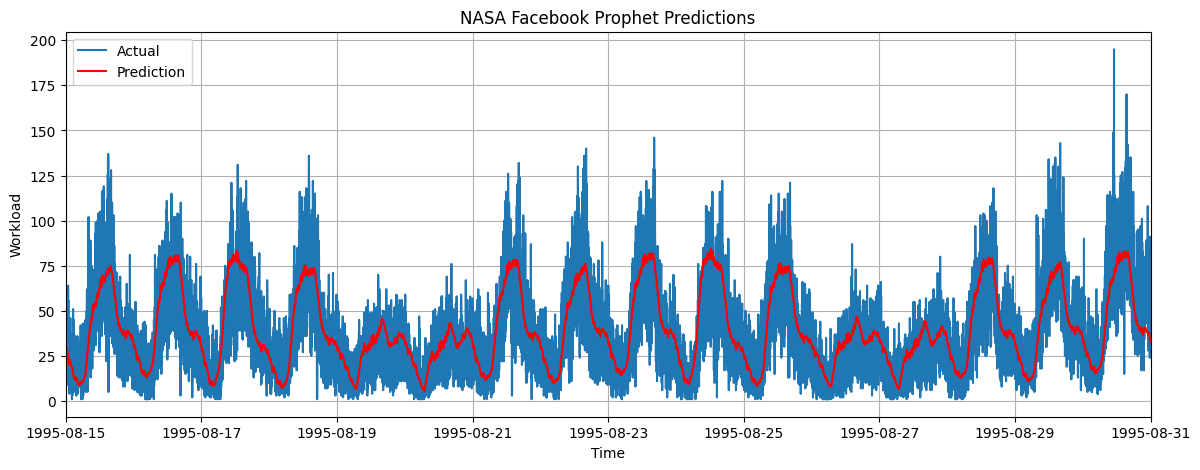

In [13]:
plt.figure(figsize=(14, 5))
# plt.plot(train_df_nasa['ds'], train_df_nasa['y'], label='Train', color='green')
plt.plot(test_df_nasa['ds'], test_df_nasa['y'], label='Actual', color='#1f77b4')
plt.plot(forecast_test_df_nasa['ds'], forecast_test_df_nasa['yhat'], label='Prediction', color='red')
plt.title('NASA Facebook Prophet Predictions')
plt.xlim(pd.to_datetime('1995-08-15'), pd.to_datetime('1995-08-31'))
plt.xlabel('Time')
plt.ylabel('Workload')
plt.grid(True)
plt.legend()
plt.savefig("images/nasa-prophet-output.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

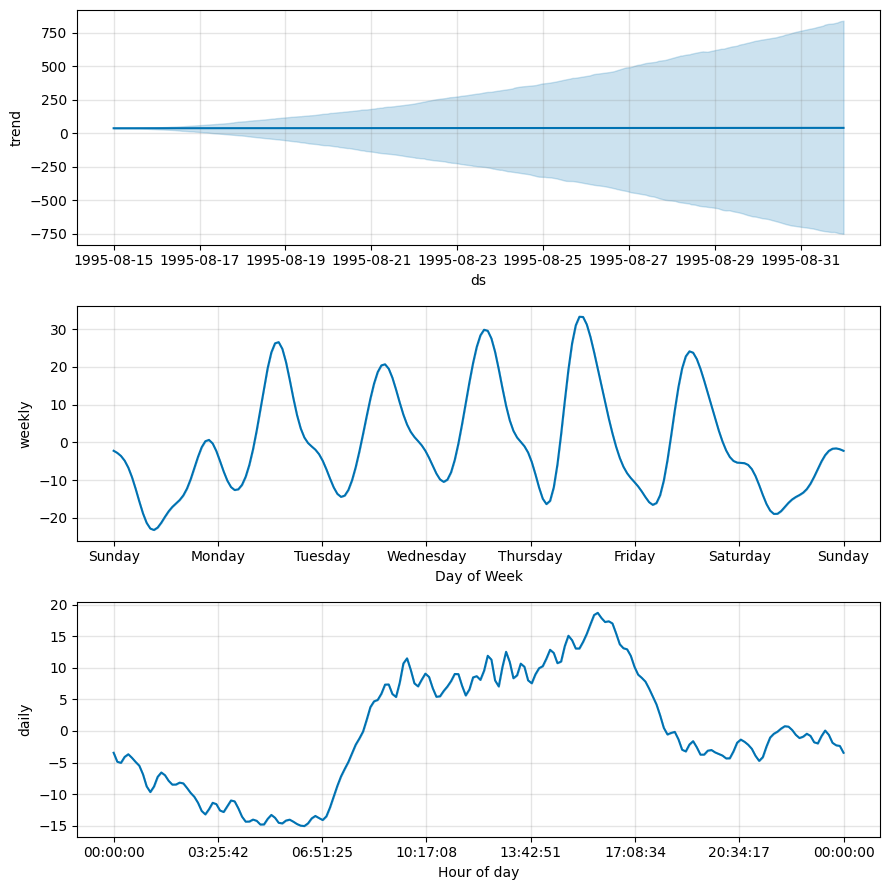

In [14]:
components_fig = model_one.plot_components(forecast_test_df_nasa)
ax_weekly = components_fig.get_axes()[1]
ax_daily = components_fig.get_axes()[2]

plt.figure(figsize=(14, 5))
plt.plot(ax_weekly.lines[0].get_xdata(), ax_weekly.lines[0].get_ydata())
plt.title('NASA Seasonality Weekly Component')
plt.xlabel(ax_weekly.get_xlabel())
plt.ylabel(ax_weekly.get_ylabel())
plt.grid(True)
plt.savefig("images/nasa-prophet-weekly.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.close()


plt.figure(figsize=(14, 5))
plt.plot(ax_daily.lines[0].get_xdata(), ax_daily.lines[0].get_ydata())
plt.title('NASA Seasonality Daily Component')
plt.xlabel(ax_daily.get_xlabel())
plt.ylabel(ax_daily.get_ylabel())
plt.grid(True)
plt.savefig("images/nasa-prophet-daily.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.close()

## Merge Forecasted Data

In [15]:
forecast_df_nasa = pd.concat([forecast_train_df_nasa, forecast_test_df_nasa])

## Residual Analysis

### Calculate Residuals

In [16]:
df_nasa_residual = df_nasa.merge(forecast_df_nasa[['ds', 'yhat']], on='ds', how='left')
df_nasa_residual['residual'] = df_nasa_residual['y'] - df_nasa_residual['yhat']
df_nasa_residual.head()

,ds,y,yhat,residual
0,1995-07-01 00:00:00,42,48.530058,-6.530058
1,1995-07-01 00:01:00,61,48.308621,12.691379
2,1995-07-01 00:02:00,57,48.083757,8.916243
3,1995-07-01 00:03:00,71,47.861055,23.138945
4,1995-07-01 00:04:00,70,47.646194,22.353806


### Prepare Dataset for LSTM

In [17]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_df_nasa = scaler.fit_transform(df_nasa_residual[['residual']])

In [18]:
def create_dataset(dataset, look_back):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

In [19]:
look_back = 1
X_nasa, y_nasa = create_dataset(scaled_df_nasa, look_back)

In [20]:
X_train_nasa, X_test_nasa, y_train_nasa, y_test_nasa = train_test_split(X_nasa, y_nasa, test_size=0.3, random_state=42, shuffle=False)

X_train_nasa = np.reshape(X_train_nasa, (X_train_nasa.shape[0], X_train_nasa.shape[1], 1))
X_test_nasa = np.reshape(X_test_nasa, (X_test_nasa.shape[0], X_test_nasa.shape[1], 1))

print(f'NASA DATASET: Train Set: {X_train_nasa.shape} | Test Set: {X_test_nasa.shape}')

NASA DATASET: Train Set: (56976, 1, 1) | Test Set: (24419, 1, 1)


### Model Definition

In [21]:
model_two = None

#### Early Stopping

In [22]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

#### HyperParameter Tuning (If Enabled)

In [23]:
def build_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('units', min_value=32, max_value=512, step=32), return_sequences=True, input_shape=(look_back, 1)))
    model.add(LSTM(units=hp.Int('units', min_value=32, max_value=512, step=32), return_sequences=False))
    model.add(Dense(1))
    
    model.compile(optimizer=hp.Choice('optimizer', values=['adam', 'rmsprop']), loss='mean_squared_error')
    return model

In [24]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=2,
    directory='hyperparam_tuning',
    project_name='lstm_hyperparam_tuning'
)

c:\Users\dilee\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [25]:
if HYPERPARAMETER_TUNING:
    tuner.search(X_train_nasa, y_train_nasa, epochs=50, batch_size=16, validation_split=0.2, callbacks=[early_stopping], verbose=1)

In [26]:
if HYPERPARAMETER_TUNING:
    model_two = tuner.get_best_models(num_models=1)[0]
    model_two_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
    print(f"Units: {model_two_hyperparameters.get('units')}")
    print(f"Optimizer: {model_two_hyperparameters.get('optimizer')}")

#### Default Model

In [27]:
if not HYPERPARAMETER_TUNING:
    model_two = Sequential()
    model_two.add(LSTM(50, return_sequences=True, input_shape=(look_back, 1)))
    model_two.add(LSTM(50, return_sequences=False))
    model_two.add(Dense(1))
    model_two.compile(optimizer='adam', loss='mean_squared_error')

Print Model Summery

In [28]:
model_two.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

### Train Model

In [29]:
model_two.fit(X_train_nasa, y_train_nasa, epochs=20, batch_size=16, validation_split=0.2, callbacks=[early_stopping], verbose=1)

Epoch 1/20
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 0.0022 - val_loss: 0.0012
Epoch 2/20
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 3/20
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 4/20
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 5/20
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 6/20
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0015 - val_loss: 0.0013


### Predict Dataset

In [30]:
nasa_train_predict = model_two.predict(X_train_nasa)
nasa_train_predict = scaler.inverse_transform(nasa_train_predict)
y_train_nasa_org = scaler.inverse_transform([y_train_nasa])

start_time = time.time()
nasa_test_predict = model_two.predict(X_test_nasa)
end_time = time.time()
nasa_test_predict = scaler.inverse_transform(nasa_test_predict)
y_test_nasa_org = scaler.inverse_transform([y_test_nasa])

print(f'NASA DATASET - Prediction Size Train: {len(nasa_train_predict)} | Prediction Size Test: {len(nasa_test_predict)}')

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
764/764 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
NASA DATASET - Prediction Size Train: 56976 | Prediction Size Test: 24419


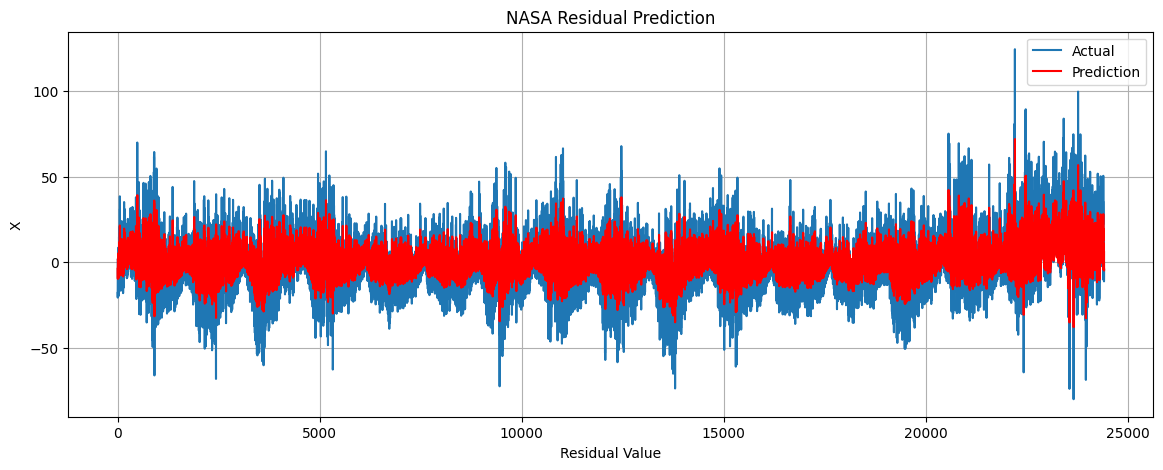

In [31]:
plt.figure(figsize=(14,5))
plt.plot(y_test_nasa_org[0], label='Actual', color='#1f77b4')
plt.plot(nasa_test_predict, label='Prediction', color='red')
plt.xlabel('Residual Value')
plt.ylabel('X')
plt.title('NASA Residual Prediction')
plt.legend()
plt.grid(True)
plt.savefig("images/nasa-lstm-output.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [32]:
mse = mean_squared_error(y_test_nasa_org[0], nasa_test_predict)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_nasa_org[0], nasa_test_predict)
r2 = r2_score(y_test_nasa_org[0], nasa_test_predict)
model_two_time = (end_time - start_time) * 1000

print('=== LSTM Residual Analysis Model Metrics ===')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'R2: {r2}')
print(f'Prediction Time: {model_two_time}ms')

=== LSTM Residual Analysis Model Metrics ===
MSE: 204.92730248303417
RMSE: 14.315282130752232
MAE: 10.934020788434779
R2: 0.22815695678556225
Prediction Time: 1256.0513019561768ms


## Combine Results from Both Models

In [33]:
nasa_combine_predict = np.concatenate((nasa_train_predict, nasa_test_predict))

final_df_nasa = df_nasa_residual.copy()

final_df_nasa['residual_predict'] = np.nan
final_df_nasa['residual_predict'].iloc[0:len(nasa_combine_predict)] = nasa_combine_predict[:, 0]
print(f'NASA DATASET: Total Output: {final_df_nasa.shape[0]} | Loss: {final_df_nasa['residual_predict'].isna().sum()}')

final_df_nasa['residual_predict'] = final_df_nasa['residual_predict'].fillna(final_df_nasa['residual'])

final_df_nasa['y_predicted'] = final_df_nasa['yhat'] + final_df_nasa['residual_predict']

final_df_nasa.head()

NASA DATASET: Total Output: 81396 | Loss: 1


C:\Users\dilee\AppData\Local\Temp\ipykernel_27980\867113017.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  final_df_nasa['residual_predict'].iloc[0:len(nasa_combine_predict)] = nasa_combine_predict[:, 0]
C:\Users\dilee\AppData\Local\Tem

,ds,y,yhat,residual,residual_predict,y_predicted
0,1995-07-01 00:00:00,42,48.530058,-6.530058,-2.472193,46.057866
1,1995-07-01 00:01:00,61,48.308621,12.691379,7.533801,55.842422
2,1995-07-01 00:02:00,57,48.083757,8.916243,5.544118,53.627876
3,1995-07-01 00:03:00,71,47.861055,23.138945,13.102928,60.963983
4,1995-07-01 00:04:00,70,47.646194,22.353806,12.681190,60.327383


### Extract Test Dataset Related Dataframe & Calculate Metrics

In [34]:
final_df_nasa_analysis = final_df_nasa.iloc[train_df_nasa.shape[0]:]
final_df_nasa_analysis.tail()

print(f'NASA DATASET: Testing Output: {final_df_nasa_analysis.shape}')

NASA DATASET: Testing Output: (24419, 6)


In [35]:
mse = mean_squared_error(final_df_nasa_analysis['y'], final_df_nasa_analysis['y_predicted'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(final_df_nasa_analysis['y'], final_df_nasa_analysis['y_predicted'])
r2 = r2_score(final_df_nasa_analysis['y'], final_df_nasa_analysis['y_predicted'])

print('=== Hybrid Model Metrics ===')
print(f'MSE: {mse:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'MAE: {mae:.3f}')
print(f'R²: {r2:.3f}')
print(f'Prediction Time: {model_one_time + model_two_time}ms')

=== Hybrid Model Metrics ===
MSE: 65.057
RMSE: 8.066
MAE: 6.256
R²: 0.898
Prediction Time: 6517.078399658203ms


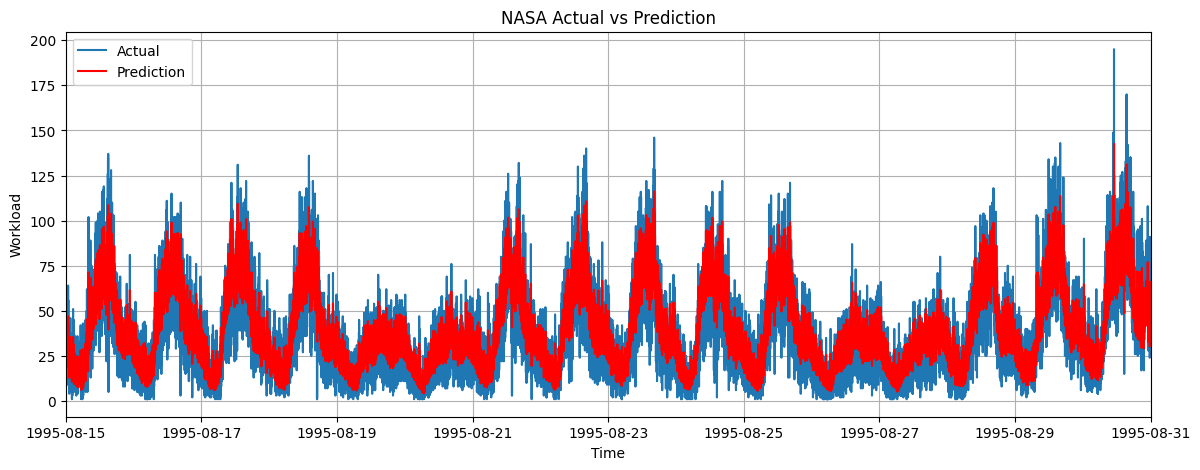

In [36]:
plt.figure(figsize=(14, 5))
# plt.plot(train_df_nasa['ds'], train_df_nasa['y'], label='Train', color='green')
plt.plot(test_df_nasa['ds'], test_df_nasa['y'], label='Actual', color='#1f77b4')
plt.plot(final_df_nasa_analysis['ds'], final_df_nasa_analysis['y_predicted'], label='Prediction', color='red')
plt.xlim(pd.to_datetime('1995-08-15'), pd.to_datetime('1995-08-31'))
plt.title('NASA Actual vs Prediction')
plt.xlabel('Time')
plt.ylabel('Workload')
plt.grid(True)
plt.legend()
plt.savefig("images/nasa-final-output.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

## Save Models

In [37]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

filename = f'models/fbprophet-nasa-{timestamp}.json'
with open(filename, 'w') as fout:
    fout.write(model_to_json(model_one))

filename = f'models/lstm-nasa-{timestamp}.keras' 
model_two.save(filename)